# Stage 8 — Noise Robustness

In this stage we evaluate how robust our models are to **additive noise** and **compression artifacts**.

We focus on:

- HuBERT and WavLM (base transformers from Stage 6)
- Their corresponding **fusion models** (transformer + acoustic features from Stage 7)

All experiments use the **same speaker-disjoint split** (`results/split.json`). Results are produced by `scripts/run_noise_robustness.py` and saved to `results/noise_robustness.json`.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve results dir: works from notebooks/ or project root
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
noise_path = root / "results" / "noise_robustness.json"
if not noise_path.exists():
    raise FileNotFoundError(
        f"Run first: python scripts/run_noise_robustness.py\n"
        f"Expected: {noise_path}"
    )

with open(noise_path) as f:
    data = json.load(f)

print("Keys:", list(data.keys()))
print("Noisy conditions:", list(data.get("noisy", {}).keys()))

Keys: ['clean', 'noisy', 'tables', 'analysis']
Noisy conditions: ['compression_0dB', 'compression_10dB']


In [2]:
def build_plot_data(data):
    """
    Convert noise_robustness.json to lists for plotting.
    Returns: (x_labels, series_auc, series_f1)
    """
    clean = data["clean"]
    noisy = data.get("noisy", {})

    # Conditions like "compression_0dB" -> (noise_type, snr)
    conditions = sorted(noisy.keys(), key=lambda k: (k.split("_")[0], int(k.split("_")[1].replace("dB", ""))))
    # Higher SNR = less noise; order clean → 10dB → 0dB (noisier)
    snrs = sorted(set(int(c.split("_")[1].replace("dB", "")) for c in conditions), reverse=True)
    x_labels = ["clean"] + [f"{s}dB" for s in snrs]

    models = [m for m in ["hubert_base_ls960", "wavlm"] if data["clean"].get("base", {}).get(m) or data["clean"].get("fusion", {}).get(m)]
    if not models:
        models = ["hubert_base_ls960", "wavlm"]

    series_auc = {}
    series_f1 = {}

    for variant in ["base", "fusion"]:
        for mn in models:
            label = f"{mn} ({variant})"
            auc_vals = [clean.get(variant, {}).get(mn, {}).get("auc_roc", np.nan)]
            f1_vals = [clean.get(variant, {}).get(mn, {}).get("f1", np.nan)]
            for snr in snrs:
                # Find condition(s) with this SNR; take mean if multiple (e.g. white_0dB, compression_0dB)
                vals_auc, vals_f1 = [], []
                for c in conditions:
                    if int(c.split("_")[1].replace("dB", "")) == snr:
                        m = noisy.get(c, {}).get(variant, {}).get(mn) or {}
                        vals_auc.append(m.get("auc_roc", np.nan))
                        vals_f1.append(m.get("f1", np.nan))
                auc_vals.append(np.nanmean(vals_auc) if vals_auc else np.nan)
                f1_vals.append(np.nanmean(vals_f1) if vals_f1 else np.nan)
            series_auc[label] = auc_vals
            series_f1[label] = f1_vals

    return x_labels, series_auc, series_f1

x_labels, series_auc, series_f1 = build_plot_data(data)
print("X labels:", x_labels)
print("Models:", list(series_auc.keys()))

X labels: ['clean', '10dB', '0dB']
Models: ['hubert_base_ls960 (base)', 'wavlm (base)', 'hubert_base_ls960 (fusion)', 'wavlm (fusion)']


## Results Overview

Grouped bar charts below compare **AUC-ROC** and **F1** across conditions (clean → 10 dB → 0 dB compression). Each condition shows four models: HuBERT and WavLM in both **base** (transformer-only) and **fusion** (transformer + acoustic features) configurations.

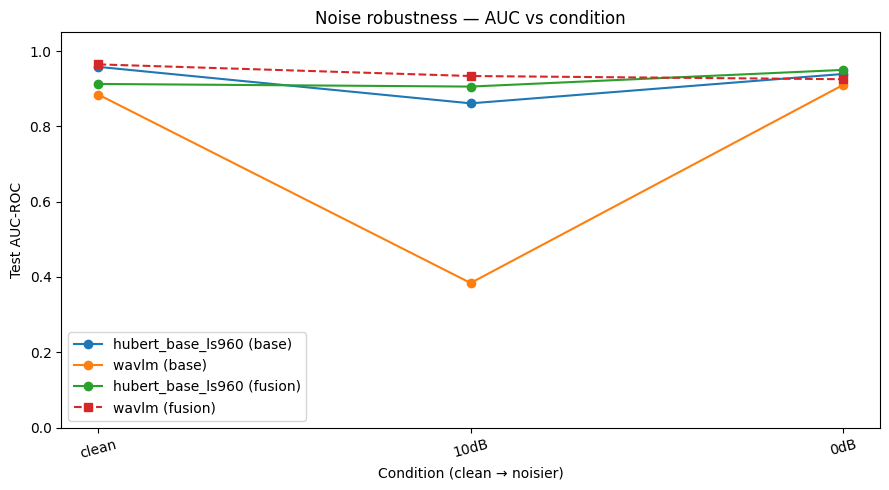

In [3]:
# --- Bar charts: clear overview of results ---
def short_label(k):
    m = "HuBERT" if "hubert" in k else "WavLM"
    v = "base" if "base" in k else "fusion"
    return f"{m} ({v})"

n_cond = len(x_labels)
n_models = len(series_auc)
x = np.arange(n_cond)
width = 0.8 / n_models
offset = (n_models - 1) * width / 2

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71", "#27ae60", "#3498db", "#2980b9"]  # green for base, blue for fusion
for i, (label, vals) in enumerate(series_auc.items()):
    pos = x - offset + i * width
    bars = ax.bar(pos, vals, width, label=short_label(label), color=colors[i], edgecolor="white", linewidth=0.5)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f"{b.get_height():.2f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_xlabel("Condition (clean → noisier)")
ax.set_ylabel("Test AUC-ROC")
ax.set_ylim(0, 1.15)
ax.set_title("Noise Robustness — AUC-ROC by Model and Condition")
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.legend(loc="lower left", ncol=2)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

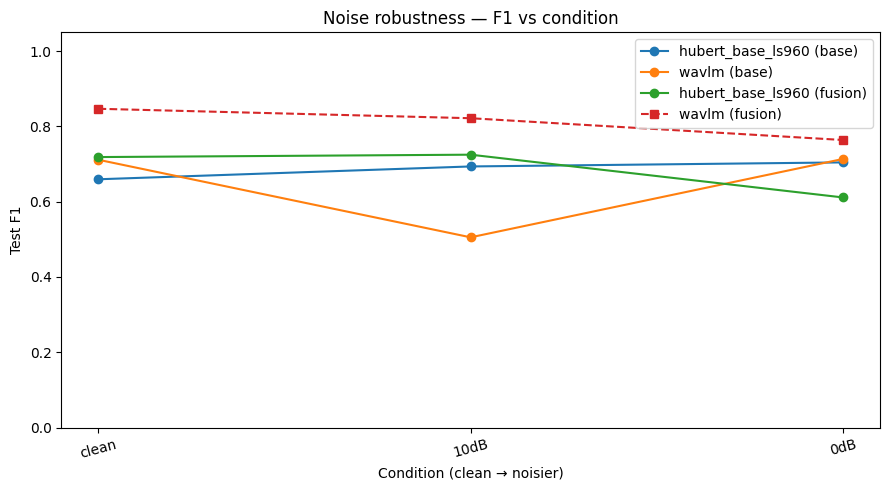

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, (label, vals) in enumerate(series_f1.items()):
    pos = x - offset + i * width
    bars = ax.bar(pos, vals, width, label=short_label(label), color=colors[i], edgecolor="white", linewidth=0.5)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f"{b.get_height():.2f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_xlabel("Condition (clean → noisier)")
ax.set_ylabel("Test F1")
ax.set_ylim(0, 1.15)
ax.set_title("Noise Robustness — F1 by Model and Condition")
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.legend(loc="lower left", ncol=2)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [5]:
# Summary tables (from run_noise_robustness.py)
if "tables" in data:
    for noise_type, rows in data["tables"].items():
        df_tab = pd.DataFrame(rows)
        print(f"\n{noise_type.upper()}:")
        display(df_tab)


COMPRESSION:


,Model,Clean AUC,0dB,10dB
0,hubert_base_ls960 (base),0.958,0.939,0.861
1,hubert_base_ls960 (fusion),0.913,0.950,0.906
2,wavlm (base),0.884,0.910,0.384
3,wavlm (fusion),0.965,0.925,0.934


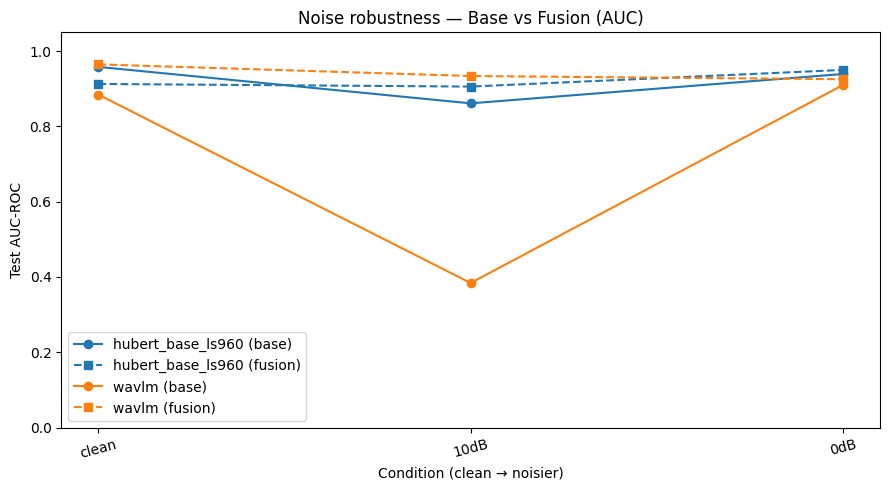

In [6]:
# Base vs Fusion — same as above but grouped by model
base_keys = [k for k in series_auc if "(base)" in k]
fusion_keys = [k for k in series_auc if "(fusion)" in k]
plt.figure(figsize=(9, 5))
for i, (bkey, fkey) in enumerate(zip(base_keys, fusion_keys)):
    plt.plot(x_labels, series_auc[bkey], "o-", label=bkey, color=colors[i])
    plt.plot(x_labels, series_auc[fkey], "--s", label=fkey, color=colors[i])
plt.xlabel("Condition (clean → noisier)")
plt.ylabel("Test AUC-ROC")
plt.ylim(0, 1.05)
plt.title("Noise robustness — Base vs Fusion (AUC)")
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Interpretation

- All models use the same **speaker-disjoint train/val/test split** and the same
  decision thresholds tuned on **validation F1** in the clean condition.

- We evaluate **HuBERT base** and **WavLM base** transformers, plus their
  **fusion models** (transformer + acoustic features from Stage 7).

- The AUC and F1 vs condition plots show how each architecture degrades from
  **clean** to **noisier** conditions (e.g. compression at 10 dB → 0 dB).

- Key findings to highlight:
  - which transformer (HuBERT vs WavLM) is most robust under compression,
  - whether fusion improves or hurts robustness under the same thresholding and split.